<div style="width: 100%; text-align: center; margin-bottom: 20px;">
  <img src="images/cabecalho_branco.jpg" alt="Cabeçalho" style="max-width: 100%; height: auto;">
</div>

# A Regularização tipo L1 e L2 aplicada à <br> Regressão Linear

**Autor**: Carlos Gabriel de Oliveira Campos

Professor Dr. **Daniel Roberto Cassar**


<--- introdução #TODO --->

---

## Uma breve introdução à Regressão Linear

A Regressão Linear é um algoritmo clássico da estatística que opera ao assumir uma relação linear entre uma ou mais variáveis independentes e uma variável dependente. Em aprendizado de máquina, esse mecanismo pode ser utilizado para *induzir* (criar) modelos preditivos cujo *target* (variável alvo) seja quantitaivo e contínuo, sendo útil para as mais diversas áreas, como:
 
- Imóveis: Prever preços de propriedades usando localização, tamanho e outros fatores.
- Finanças: A previsão de preços de ações usando taxas de juros e dados de inflação.
- Agricultura: Estimar a produção de culturas a partir de chuva, temperatura e qualidade do solo.
- E-commerce: Analisar como preço, promoções e estações afetam as vendas [1].

## Regressão Linear Simples

A principal referência para esta seção é o capítulo 3 da referência [2].

Para casos de uma única variável independente, chama-se Regressão Linear Simples a relação matemática entre dados que  pode ser representada pela fórmula **1.1**, em que as matrizes-coluna, $Y$ e $X$, representam a resposta quantitativa e a variável de previsão, respectivamente. $\beta_0$ e $\beta_1$ são os coeficientes, sendo o primeiro o *intercepto* - o valor estimado para $Y$ quando todas as variáveis independentes valem 0-, e $\beta_1$, o termo que ajusta as variáveis de X ao valor estimado. Ademais, o termo $\epsilon$ simboliza o erro aleatório, com média 0, e simboliza variações naturais e irredutíveis que impedem o modelo de prever com total precisão.

$$
\tag{1.1}
Y = \beta_0 + \beta_1 X + \epsilon 
$$

### Estimando os coeficientes

Dado um problema real, é uma grande suposição interpretá-lo como uma relação totalmente linear. Raramente ocorre de esse ser o caso de fato, e por isso $Y$ é em função de $\epsilon$ também, o qual não podemos prever. Dessa forma, a notação $\hat{Y}$ representa a resposta *estimada* por nosso modelo, o qual parte da estimativa de seus coeficientes, $\hat{\beta}_0$ e $\hat{\beta}_1$. Dessa maneira, o modelo de regressão linear simples é formulado como

$$
\tag{1.2}
\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 X
$$

O meio mais prático para essa tarefa é o *Método dos Quadrados Mínimos* $\text{(MQM)}$. Para isso, é necessário o conceito de $\text{RSS}$, do inglês, *soma dos resíduos quadráticos*. Ela funciona como um indicador da precisão do modelo, uma *função de custo*! Sendo que uma menor $\text{RSS}$ implica em uma maior precisão em relação aos dados de treino. O quadrado da diferença entre o valor real e o valor estimado serve para que erros de previsão "para mais" e "para menos" não se cancelem, da mesma forma que penaliza mais severamente erros maiores, enquanto suaviza erros menores. O conjunto dos valores estimados para os coeficientes $\beta_0, \beta_1 ... \beta_p$ é escrito como 

$$
\tag{1.3}
\text{RSS} =(y_1 − \hat{\beta}_0 −\hat{\beta}_1x_1)^2+(y_2 −\hat{\beta}_0 −\hat{\beta}_1x_2)^2 + ··· + (y_n − \hat{\beta}_0 − \hat{\beta}_1x_n)^2
$$

Quando aplicamos a derivada parcial em relação a cada coeficiente, podemos encontrar que:

$$\hat{\beta}_1 = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2}$$

$$
\tag{1.4}
\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x} 
$$

<figure align="center">
  <img src="images/rss-graphic.png" alt="Representação gráfica da RSS" width="80%">
  <figcaption> <b>Figura 1</b> <em> - Representação em contorno e tridimensional da RSS em função dos parâmetros, em que o ponto vermelho corresponde ao par de parâmetros que minimizam a RSS para um certo conjunto de dados. [ISLP - p. 73].</em></figcaption>
</figure>

Notamos, assim, que há uma dependência de $\beta_0$ em relação a $\beta_1$, o que não é favorável aos cálculos para estimar o valor dos coeficientes, visto que qualquer mudança em $\beta_1$ irá alterar $\beta_0$. Logo, é interessante centralizar $X$, o que torna a média $\tilde{\bar{x}} = 0$.

$$\tilde{x} = x_i - \bar{x}$$
$$\bar{\tilde{x}} = 0$$

Logo:

$$\hat{\beta}_0 = \bar{y}$$

Portanto, podemos reformular a equação 1.2 para:

$$
\text{RSS} = (y_1 − \beta_0 - \hat{\beta}_1 \tilde{x_1})^2 + (y_2−\beta_0 -\hat{\beta}_1\tilde{x_2})^2 + ··· + (y_n - \beta_0 − \hat{\beta}_1\tilde{x_n})^
2
$$

$$
\tag{1.5}
\text{RSS} = \sum_{i=1}^{n} (y_i - \beta_0 - \hat{\beta}_1 \tilde{x_i})^2 
$$


Agora que definimos nossa função de custo, devemos buscar como devem ser o estimadores de coeficiente $\hat{\beta_0}$ e $\hat{\beta_1}$ que minimizam a RSS. Ou seja, basta calcular as derivadas parciais da RSS em relação aos estimadores e igualar a 0, obtendo:


$$
\tag{1.6}
\hat{\beta} = (\tilde{X}^T \tilde{X})^{-1} \tilde{X}^T Y
$$

## Colocando em prática: Verificando a relação entre vendas e diferentes meios de publicidade

### Carregando dados sobre investimento em publicidade para prever o número de vendas

A tabela `Advertising` trata de quantas milhares de unidades de um produto foram vendidas (`sales`) dado uma quantidade em milhar de dólares ($1_000.00) de investimento para cada meio de comunicação para um mercado específico, sendo que estão disponíveis para anúncios `TV`, `radio` e `jornal`. Demos uma olhada nos dados!

In [120]:
import pandas as pd

# Criando DataFrame do pandas
df = pd.read_csv("data/Advertising.csv", index_col=0)
df

,TV,radio,jornal,vendas
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


Dessa forma, a primeira observação da tabela, `[230.1, 37.8, 69.2, 22.1]`, indica que em um dado mercado, investiu-se em propagandas - em dólares - 230.1 mil na TV, 37.1 mil nas rádios e 69.2 mil em matérias de jornal, resultando em 22.1 mil unidades vendidas.

### Divisão Treino-Teste pelo método *Holdout*

As observações serão particionadas entre dados para treinamento do modelo e dados para teste do modelo.
Como há apenas 200 observações (um número relativamente baixo), serão reservados 20% dos dados para teste, ao invés dos costumeiros 10% para escalas maiores.

In [121]:
from sklearn.model_selection import train_test_split

TAMANHO_TESTE = 0.2
SEMENTE = 42 

indices = df.index
indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE,
    random_state=SEMENTE
)

df_treino = df.loc[indices_treino]
df_teste = df.loc[indices_teste]

### Treinamento do modelo

Como será visto em breve, há módulos em python dedicados e bem simples com ferramentas para regressão linear, mas primeiro é necessário pegar a lógica *por debaixo dos panos*.

In [134]:
# Atribuindo cada conjunto a uma Série
x_treino = df_treino["TV"]
y_treino = df_treino["vendas"]

x_teste = df_teste["TV"]
y_teste = df_teste["vendas"]

# Obtendo médias de X
media_x_treino = x_treino.mean()
media_x_teste = x_teste.mean()

# Centralizando dados da TV
x_treino_c = x_treino - media_x_treino
x_teste_c = x_teste - media_x_teste

# Calculando os parâmetros
b1 = x_treino_c.dot(y_treino) / x_treino_c.dot(x_treino_c)
b0 = y_treino.mean()

# Calcula linha de previsão do modelo
previsao = b0 + x_teste_c * b1

### Visualizando a reta ajustada

<figure align="center">
  <img src="images/rls_vendas_tv.png" alt="Representação gráfica da RSS" width="80%">
  <figcaption> <b>Figura 2</b> <em> - Relação entre o investimento em publicidade na TV e vendas do produto.</em></figcaption>
</figure>


Na **Figura 2**, foi desenhada a linha de regressão dos valores de `TV` sobre `vendas`, a qual foi ajustada para minimizar o resíduo quadrático de cada ponto *de treino*. As linhas tracejadas em cinza representam o resíduo dos pontos em relação à reta de ajuste do modelo. 

### O quão forte é a relação entre o atributo e o alvo?

Nas estatísticas, existe uma métrica muito relevante para métodos lineares que nos ajuda a compreender a proporção de variabilidade que é explicada pelo modelo. Em outras palavras, *o quanto de $Y$ que pode ser explicado por $X$*. Assim, o **coeficiente de determinação**, ou como também é conhecido, $R^2$, é calculado como:

$$
\tag{1.7}
R^2 = \frac{\text{TSS} - \text{RSS}}{\text{TSS}} = 1 - \frac{\text{RSS}}{\text{TSS}}
$$

Dado que a *soma total dos quadrados*, $\text{TSS}$, é dada por

$$
\tag{1.8}
\text{TSS} = \sum_{i=1}^{n} (y_i - \bar{y})^2
$$

Uma medida de $R^2$ próxima de 1 significa que uma vasta proporção da variabilidade dos valores da resposta são explicadas pela regressão, enquanto um resultado próximo de 0 implica que pouco é explicado pela regressão. Isso pode decorrer por um modelo linear errado, por uma variância de erro muito alta, ou por ambos.

In [123]:
from sklearn.metrics import r2_score

r_quad_rls: float = r2_score(
    y_true=y_teste,
    y_pred=previsao
    )
print(f"R² aferido com dados de teste: {r_quad_rls:.2f}")

R² aferido com dados de teste: 0.67


O $R^2$ obtido de 0.67 indica que apenas a informação de `TV` é capaz de explicar dois terços da variância de $Y$, o que não é um resultado tão satisfatório, trazendo as implicações recém-comentadas, mas demonstra tamanha a influência dessa mídia para as vendas.


### O quão preciso foi o modelo? 


De nada adianta treinarmos um modelo, realizar as previsões, mas não medir seu desempenho. Daí surge a raíz do erro quadrático médio, do inglês, *root mean squared error* $(\text{RMSE})$. Ele é uma abrodagem amplamente utilizada por expressar a mesma unidade da variável alvo (nesse caso, unidades vendidas). Por conta de seu fator quadrático, erros maiores são penalizados mais severamente e erros menores são suavizados, o que não o torna a medida mais direta para comunicar o erro médio - como o *erro médio absoluto* ($\text{MAE}$) da equação **1.10** [3] -, mas potencializa comparações entre modelos. 


$$
\tag{1.9}
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

$$
\tag{1.10}
\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y_i}| 
$$


É importante ressaltar que essas métricas escalam com o a magnitude da variável que se está analisando, portanto, avaliar a qualidade de um modelo por esses meios requer também analisar a escala do target. Sob essa perspectiva, surgem formas alternativas de *normalizar* a $\text{RMSE}$ de modo que desempenhos de modelos sobre diferentes atributos possam ser comparados, como pela média (1.11), pela diferença entre o máximo e o mínimo (1.12), pelo desvio padrão (1.13) ou pela amplitude interquartil (1.14) https://www.marinedatascience.co/blog/2019/01/07/normalizing-the-rmse/ [?]. Cada uma possui sitauações espécificas ideais de aplicação, as quais não serão aprofundadas nessa discussão, mas que requerem uma ponderação sobre a natureza dos dados da resposta previamente à aplicação.


$$
\tag{1.11}
\text{NRMSE} = \dfrac{\text{RMSE}}{\bar{y}}
$$

$$
\tag{1.12}
\text{NRMSE} = \dfrac{\text{RMSE}}{y_{max} - y_{min}}
$$

$$
\tag{1.13}
\text{NRMSE} = \dfrac{\text{RMSE}}{\sigma}
$$

$$
\tag{1.14}
\text{NRMSE} = \dfrac{\text{RMSE}}{Q_3 - Q_1}
$$


A $\text{NRMSE}$ será avaliada sobre a média das vendas, uma vez que os números de vendas das observações são apenas valores positivos, unimodais (cuja distribuição apresenta apenas um pico de concentração) e relativamente siméricos, o que favorece essa abordagem.

In [124]:
from sklearn.metrics import root_mean_squared_error

rmse_rls: float = root_mean_squared_error(
    y_true=y_teste, 
    y_pred=previsao
    )
print(
    f"RMSE: {rmse_rls:.2f}",
    f"NMRSE pela média: {rmse_rls / df["vendas"].mean():.2f}",
    sep="\n"
    )

RMSE: 3.20
NMRSE pela média: 0.23


Ou seja, o modelo de regressão linear simples obteve um RMSE de 3.20 unidades vendidas, o que se traduz em 23% do valor da média das vendas. Esse não é um bom resultado, mas também não é terrível. Dessa forma, pode-se perceber como a publicidade na televisão é um preditor muito interessante para o número de vendas do produto. Ao mesmo tempo, é essencial reconhecer sua insuficiência: ele faz uma análise geral com base em apenas uma única variável, quando, na realidade, há muitos outros fatores que podem influenciar as vendas, como outros meios de publicidade, a imagem pública sobre a marca, entre outros. 

É sempre importante ponderar qual modelo é o mais adequado a cada cenário, e tendo agora meios para medir a qualidade do modelo, por que não compará-lo a outro? E se... e se analisarmos mais de um atributo para um mesmo target!? Talvez nossa previsão fique melhor.

## Regressão Linear Múltipla

A principal referência para esta seção é o capítulo 3 da referência [2].

Como foi sugerido, a Regressão Linear Múltipla (RLM) emerge para induzir modelos com base em 2 *ou mais* preditores simultaneamente. Isso nos permite ter uma compreensão mais profunda das associações entre as variáveis em consideração, mas também requer um novo leque de sensibilidades para trabalhar adequadamente com a nova ferramenta. A base estatística é similar à de Regressão Linear Simples, sendo que a resposta e a RSS assumem a forma:

$$
\tag{2.1}
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_p X_p 
$$

$$
\text{RSS} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
$$

$$
⠀⠀⠀⠀= \sum_{i=1}^{n} (y_i - \hat{\beta_0} - \hat{\beta_1} x_{i1} - \hat{\beta_2} x_{i2} - ... - \hat{\beta_p} x_{ip})^2
$$

$$
\tag{2.2}
= \sum_{i=1}^{n} (y_i - \hat{\beta_0} - \sum_{j=1}^{p}\hat{\beta_p} x_{ij})^2⠀⠀⠀⠀⠀⠀
$$


### Implementação de RLM com `sci-kit`: treinamento

<------ (a elaborar) Podemos nos basear também na radio para prever as vendas...

In [125]:
from sklearn.linear_model import LinearRegression

# Atribuindo Pandas/Séries a cada conjunto
X_treino_rlm = df_treino[["TV", "radio"]]
X_teste_rlm = df_teste[["TV", "radio"]]

# Instanciando modelo
modelo_rlm = LinearRegression()

# Treinando modelo
modelo_rlm.fit(X_treino_rlm, y_treino)

# Gerando previsão
previsao_rlm = modelo_rlm.predict(X_teste_rlm)

In [126]:
r_quad_rlm = r2_score(
    y_true=y_teste,
    y_pred=previsao_rlm)

rmse_rlm = root_mean_squared_error(
    y_true=y_teste, 
    y_pred=previsao_rlm
    )
print(
    f"R² aferido com dados de teste: {r_quad_rlm:.2f}",
    f"RMSE: {rmse_rlm:.2f}",
    f"NMRSE pela média: {rmse_rlm / df["vendas"].mean():.2f}",
    sep="\n"
    )

R² aferido com dados de teste: 0.90
RMSE: 1.77
NMRSE pela média: 0.13


### Visualização dos resultados


<figure align="center">
  <img src="images/sup_reg_3d_.png" height="480" style="margin-right: 30px;" />
  <img src="images/desempenho_rlm.png" height="480" />
  <figcaption> <b>Figura 3</b> <em> - Legenda (TODO) <em></figcaption>
</figure>


À esquerda, uma representação em 3D da superfície de regressão e do desempenho do modelo. Os pontos vermelhos indicam pontos de dado de teste, enquanto as linhas tracejadas, o resíduo.

### Avaliando o modelo de RLM

Olha só! Agora vemos em 3D! Com essa visualização, podemos notar que $\hat{f}(X)$ - o valor previsto - assume um maior valor seguindo a linha reta entre os eixos de Radio e de TV. Isso pode ser compreendido porque ela consiste dos pontos em que o investimento em ambas as modalidades de anúncios são maximizados. Logo, as vendas também serão maximizadas. Sob outro ponto de vista, dado um orçamento, é notório que deve-se investir mais em propagandas televisivas do que na rádio, uma vez que as primeiras apresentam um maior retorno anúncio-vendas. 

Além disso, o gráfico sobre o desemepenho do modelo nos oferece uma observação comparativa com o outro gráfico. Pode-se notar como a previsão possui erros maiores (mas relativamente pequenos!) no início da reta, mas fica substancialmente mais preciso para maiores valores de `vendas`.

Feita a regressão, torna-se possível verificar as métricas de seu desempenho por meio de $R^2$ e do $\text{RMSE}$.

<table style="width: 700px; border-collapse: collapse; margin: 0 auto; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; border-radius: 8px; overflow: hidden; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); border: 1px solid #cbd5e1;">
  <thead>
    <tr style="background-color: #0f172a; color: #ffffff; text-align: left; font-size: 14px;">
      <th style="padding: 12px 16px; border: 1px solid #334155;">Modelo</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">R²</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">RMSE</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #ffffff;">
      <td style="padding: 12px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">RL Simples</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.67</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">3.20 un.</td>
    </tr>
    <tr style="background-color: #f8fafc;">
      <td style="padding: 12px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">RL Múltipla</td>
      <td style="padding: 12px 16px; text-align: center; font-weight: 600; color: #0f172a; border: 1px solid #e2e8f0;">0.90</td>
      <td style="padding: 12px 16px; text-align: center; font-weight: 600; color: #0f172a; border: 1px solid #e2e8f0;">1.77 un.</td>
    </tr>
  </tbody>
</table>

Isso mesmo, o $\text{RMSE}$ despencou quase pela metade ao introduzir o novo preditor `radio`! Esse resultado, em conjunto com um aumento significativo de $R^2$, nos diz que o modelo foi muito aprimorado pelas contribuições dos novos dados introduzidos para treinamento, explicando melhor a variação de $Y$ e reduzindo significativamente os erros de previsão.

Sob essa lógica, por que não apenas continuar adicionando parâmetros, como `jornal`?

### A adição da nova variável `jornal` e suas consequências

A seleção de atributos que serão incorporados ao treinamento de modelos regressivos é um tópico de vasta profundidade, visto que há diversas sutilezas que precisam ser analisadas de antemão. A princípio, podemos checar a *matriz de correlação*, a qual relaciona cada variável da nossa tabela, de dois a dois, com o respectivo valor de *correlação de Pearson* ($r$), o qual indica a força e direção da relação linear entre duas variáveis contínuas. $r$ igual a 0 aponta nenhum padrão linear reconhecido, próximo a 1 indica uma tendência de proporcionalidade direta, e próximo a -1, o inverso disso [4].

$$
\tag{2.3}
r(X, Y) = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}
$$

In [70]:
# Mostra a correlação de Pearson entre todos os preditores
matriz_corr = df.corr()

<table style="width: 100%; border-collapse: collapse; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; border-radius: 8px; overflow: hidden; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); font-size: 13.5px; border: 1px solid #cbd5e1;">
  <thead>
    <tr style="background-color: #0f172a; color: #ffffff;">
      <th style="padding: 12px 16px; text-align: left; border: 1px solid #334155;">Variável</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">TV</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">Rádio</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">Jornal</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">Vendas</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">TV</td>
      <td style="padding: 10px 14px; text-align: center; color: #94a3b8; background-color: #f8fafc; border: 1px solid #e2e8f0;">1.0</td>
      <td style="padding: 10px 14px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.05</td>
      <td style="padding: 10px 14px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.06</td>
      <td style="padding: 10px 14px; text-align: center; font-weight: bold; color: #1e293b; border: 1px solid #e2e8f0;">0.78</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">Rádio</td>
      <td style="padding: 10px 14px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.05</td>
      <td style="padding: 10px 14px; text-align: center; color: #94a3b8; background-color: #f8fafc; border: 1px solid #e2e8f0;">1.0</td>
      <td style="padding: 10px 14px; text-align: center; background-color: #fee2e2; color: #991b1b; font-weight: 600; border: 1px solid #fca5a5;">0.35</td>
      <td style="padding: 10px 14px; text-align: center; font-weight: bold; color: #1e293b; border: 1px solid #e2e8f0;">0.58</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">Jornal</td>
      <td style="padding: 10px 14px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.06</td>
      <td style="padding: 10px 14px; text-align: center; background-color: #fee2e2; color: #991b1b; font-weight: 600; border: 1px solid #fca5a5;">0.35</td>
      <td style="padding: 10px 14px; text-align: center; color: #94a3b8; background-color: #f8fafc; border: 1px solid #e2e8f0;">1.0</td>
      <td style="padding: 10px 14px; text-align: center; background-color: #fef3c7; color: #92400e; font-weight: 600; border: 1px solid #fcd34d;">0.23</td>
    </tr>
    <tr style="background-color: #f1f5f9;">
      <td style="padding: 10px 16px; font-weight: 700; color: #0f172a; border: 1px solid #cbd5e1;">Vendas</td>
      <td style="padding: 10px 14px; text-align: center; font-weight: bold; color: #0f172a; border: 1px solid #cbd5e1;">0.78</td>
      <td style="padding: 10px 14px; text-align: center; font-weight: bold; color: #0f172a; border: 1px solid #cbd5e1;">0.58</td>
      <td style="padding: 10px 14px; text-align: center; background-color: #fef3c7; color: #92400e; font-weight: 700; border: 1px solid #fcd34d;">0.23</td>
      <td style="padding: 10px 14px; text-align: center; color: #94a3b8; background-color: #f8fafc; border: 1px solid #cbd5e1;">1.0</td>
    </tr>
  </tbody>
</table>

Com enfoque na análise de `jornal`, é válido destacar sua fraca correlação com `vendas` quando comparada àquela de outros meios, de 23%, além de que essa variável tem uma associação comprometedora com `radio`, de 35%! Traduzindo: mercados em que investe-se bem em rádio tendem a ter investimento similar nos jornais, e como `radio` tem um bom engajamento com `vendas`, a importância de `jornal` para prever `vendas` é "carregada" por `radio`. Esse fenômeno é chamado de colinearidade, em que o modelo não consegue separar as contribuições individuais das variáveis. 

Desse modo, uma variável que realmente tem influência sobre a resposta pode parecer insignificante simplesmente porque ela partilha de muita informação com outra no modelo. Ainda pior, os estimadores de coeficiente tornam-se instáveis, visto que adicionar ou remover um único ponto de dado ou uma variável do treinamento pode alterar drasticamente os demais coeficientes. Todos esses problemas não necessariamente se materializam em grandes erros ou declínio da precisão, mas fazem com que o modelo não enxergue a contribuição verdadeira de cada atributo [5].

De fato, a tabela a seguir mostra como a inclusão de `jornal` para o treinamento do modelo aumenta o $\text{RMSE}$ e reduz o $R^2$, mesmo que por pequeníssimas margens.

<table style="width: 100%; border-collapse: collapse; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; border-radius: 8px; overflow: hidden; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); font-size: 13.5px; border: 1px solid #cbd5e1;">
  <thead>
    <tr style="background-color: #0f172a; color: #ffffff;">
      <th style="padding: 12px 16px; text-align: left; border: 1px solid #334155;">Modelo</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">&beta;&#770;<sub>0</sub></th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">&beta;&#770;<sub>1</sub> (TV)</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">&beta;&#770;<sub>2</sub> (Rádio)</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">&beta;&#770;<sub>3</sub> (Jornal)</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">R&sup2 (teste)</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">RMSE</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #ffffff;">
      <td style="padding: 11px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">RLM (TV + Rádio)</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">3.028</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">0.044</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">0.191</td>
      <td style="padding: 11px 14px; text-align: center; color: #94a3b8; border: 1px solid #e2e8f0;">&mdash;</td>
      <td style="padding: 11px 14px; text-align: center; font-weight: 600; color: #0f172a; border: 1px solid #e2e8f0;">0.900</td>
      <td style="padding: 11px 14px; text-align: center; font-weight: 600; color: #0f172a; border: 1px solid #e2e8f0;">1.771</td>
    </tr>
    <tr style="background-color: #f8fafc;">
      <td style="padding: 11px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">RLM (TV + Rádio + Jornal)</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">2.979</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">0.044</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">0.189</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">0.003</td>
      <td style="padding: 11px 14px; text-align: center; font-weight: 600; color: #0f172a; border: 1px solid #e2e8f0;">0.899</td>
      <td style="padding: 11px 14px; text-align: center; font-weight: 600; color: #0f172a; border: 1px solid #e2e8f0;">1.782</td>
    </tr>
  </tbody>
</table>

Vale ressaltar que a correlação de Pearson não é a única forma de aferir a correlação, com a correlaçao de Spearman sendo outra poderosa alternativa. Entretanto, a de Pearson é mais adequada para esse cenário, uma vez que todas as variáveis são contínuas, não há muitos *outliers* (valores anômalos), além de que presumimos uma relação linear entre as variáveis e que a relação delas segue uma linha reta [6?].

## A seleção de atributos, viés e variância

A principal referência para esta seção é a subseção 2.2.2 e o capítulo 6 da referência [2].

A investigação que fizemos acerca da variável `jornal` no último tópico tem um importante propósito didático e logrou êxito especialmente porque o número de variáveis era pequeno em comparação com o que é usualmente trabalhado. Mas realizar essa investigação em problemas reais seria imprático e tornaria exaustivo o processo de determinar quais variáveis serão encarregadas de treinar nosso modelo e em que grau o farão. Por curiosidade, pesquisadores da área da genética geralmente lidam com **milhares** de variáveis [6]. Como veremos, existem formas alternativas de ajuste que são capazes de aperfeiçoar a precisão e interpretabilidade do modelo.

### O dilema Viés-Variância 

Acerca de todos os tipos de modelo de aprendizado de máquina, permeia esse dilema conhecido em inglês como *Bias-Variance Trade-off*. Ele parte de duas métricas que são chaves para essa ciência:

- **Variância**: mede o quanto que $\hat{f}$ mudaria se usássemos diferentes dados para treinar o modelo. Ou seja, uma maior variância implica que as estimativas de coeficientes seriam substancialmente alteradas por pequenas mudanças nos dados de treino, o que não é o ideal. No geral, métodos estatísticos com mais variância tendem a ser mais flexíveis, isto é, com maior facilidade para se ajustar a diferentes padrões.

- **Viés**: afere o erro introduzido no modelo quando ele é aproximado à realidade. Ou seja, é quando um problema real - muito complexo - é simplificado, o que dificilmente caracteriza corretamente todos os fatores que influenciam um evento ou objeto. Nesse contexto, o MQM propõe uma relação linear entre os dados, quando na realidade é muito raro que isso de fato ocorra. Por exemplo, a aplicação dessa técninca a um problema cúbico (não linear) resulta em um alto viés, enquanto o problema das vendas visto anteriormente possui um baixo viés.

Pode ser provado matematicamente que o erro quadrático médio - $\text{MSE}$ - esperado para o teste, em um determinado ponto $x_0$, pode ser decomposto em três quantias fundamentais: a *variância* de $\hat{f}(x_0)$, o viés quadrático de $\hat{f}(x_0)$ e a variância dos termos de erro $\epsilon$.

$$
\tag{3.1}
E[\text{MSE}] = \text{Var}(\hat{f}(x_0)) + [\text{Viés}(\hat{f}(x_0))]^2 + \text{Var}(\epsilon)
$$

Dado que $E[\text{MSE}]$ representa o *valor esperado* de $\text{MSE}$, a equação **3.1** nos diz um modelo ideal apresenta tanto um baixo viés como uma baixa variânica.

### Por que regularizar os atributos pode nos ajudar com o dilema?

- Desempenho: dada uma relação aproximadamente linear entre preditores e resposta, o modelo induzido via $\text{MQM}$ terá um baixo viés. Se o número de obsrevações for muito maior do que o de variáveis independentes, isto é, $n >> p$, então também terá variância em um nível baixo, e assim o modelo terá um bom desempenho nos testes. Contudo, se $n$ não for muito maior do que $p$, a variância pode ser problemática para o ajuste por $\text{MQM}$, resultando em *overfitting* (sobreajuste) e, por consequência, um resultado muito impreciso nos testes. Se $p > n$, então $\text{MQM}$  passa a ter infinitas soluções. Ao *encolher* ou *restringir* os coeficientes estimados, é possível reduzir drasticamente a variância ao custo de um pequeno aumento no viés, o que torna as previsões das respostas mais certeiras para os dados de teste.

- Interpretabilidade: Frequentemente, uma parte das variáveis utilizadas em um modelo de RLM não são realmente associadas à resposta. Ao incluir essas variáveis irrelevantes, abre-se espaço para uma complexidade desnecessária do modelo final. Quando elas são removidas (o coeficiente correspondente é reduzido a 0), somos capaz de compreender melhor o comportamento do modelo - ele fica mais interpretável. A essa abordagem chama-se seleção de atributos, a qual pode assumir várias formas, como será explorado a seguir.


### Regressão Ridge

Retomemos da equação **2.2** que o ajuste por MQM estima os coeficientes ao minimizar 
$$
\text{RSS} = \sum_{i=1}^{n} \Bigg(y_i - \hat{\beta_0} - \sum_{j=1}^{p}\hat{\beta_p} x_{ij} \Bigg)^2⠀⠀⠀⠀
$$

A regressão Ridge é bem parecida com MQM, de forma que as estimativas de coeficientes $\hat{\beta}^R$ são os valores que minimizam

$$
\tag{3.2}
\sum_{i=1}^{n} \Bigg(y_i - \hat{\beta_0} - \sum_{j=1}^{p}\hat{\beta_p} x_{ij} \Bigg)^2 + \lambda \sum_{j=1}^{p} \hat{\beta}^2_p 
= \text{RSS} + \lambda \sum_{j=1}^{p} \hat{\beta}^2_p
$$

Em que $\lambda \geq 0$ é o *parâmetro de ajuste*, a ser determinado a parte. A equação **3.2** equilibra dois critéiors distintos: assim como em MQM, o ajuste é feito ao deixar RSS o menor possível, mas o segundo termo, $ \lambda \sum_{j=1}^{p} \hat{\beta}^2_p $, denominado *penalidade de encolhimento*, é minimizado quando $ \hat{\beta}_1 ... \hat{\beta}_p$ ficam próximos de zero, e então tem o efeito de encolher os estimadores $\hat{\beta}_j$ em direção a zero. O parâmetro de ajuste $\lambda$ tem o propósito de controlar o impacto relativo desses dois termos nas estimativas dos coeficientes da regressão. A regressão ridge também é conhecida como  *regularização L2* por ser proporcional ao quadrado da *norma L2*, que calcula a distância de um vetor ao ponto 0, sendo definida como $||\beta||_2 = \sqrt{\sum_{j=1}^{p} \beta_j^2}$.

<figure align="center">
  <img src="images/ridge_reg.png" alt="Representação gráfica da RSS" width=440px>
  <figcaption> <b>Figura 2</b><em> - Dez coeficientes padronizados de regressão ridge referentes aos dados </em> <code>Credito</code> <em> em função de λ. As curvas em destaque representam os quatro principais atributos. [ISLP - p. 241]</em></figcaption>
</figure>




Quando $\lambda = 0 $, o conjunto dos coeficientes estimados pela regressão ridge serão os mesmos de MQM, mas à medida que $\lambda \to \infty$, o impacto da penalidade de encolhimento cresce, e as estimativas dos coeficientes da regressão ridge vão se aproximar de zero. Diferente de MQM, que geram apenas um conjunto de estimativas de coeficientes, a regressão ridge vai produzir um conjunto diferente de estimativas de coeficientes, $\hat{\beta}_\lambda^R$, para cada valor de $\lambda$. Portanto, escolher um bom valor para $\lambda$ é crítico, o que requer *validação cruzada* (a ser discutida em breve). Repare que a penalidade de encolhimento não é aplicada ao intercepto $\hat{\beta}_0$, visto que ele é apenas o valor médio da resposta quando $x_{i1} = x_{i2} = ... = x_{ip} = 0$.

O MQM padrão é *equivariante de escala*: multiplicar $X_j$ por uma constante $c$ apenas faz o coeficiente estimado ser escalado por $1/c$. Em outras palavras, não importa a escala do $j$-ésimo preditor (ex.: $m^2$ ou $km^2$), $X_j \hat{\beta_j}$ terá o mesmo valor. Entretanto, a estimativa dos coeficientes por regressão ridge pode mudar significativamente quando se multiplica um preditor por uma constante. Por exemplo, considere a variável `renda`, cuja unidade é em dólares. Caso ela fosse medida em milahres de dólares, isso causaria uma redução dos valores desse atributo nas observações por um fator de mil. 

Assim, por conta da soma do quadrado dos coeficientes na formulação da regressão ridge, conforme a equação **3.2**, essa mudança na escala do $j$-ésimo preditor não vai afetar somente o coeficiente correspondente em uma escala de 1000, como também $X_j \hat{\beta}_{j, \lambda}^R$. Na realidade, esse valor pode até depender da escala de *outros* preditores! Desse modo, é uma boa prática aplicar a regressão ridge após *padronizar os preditores* usando a fórmula

$$
\tag{3.3}
\tilde{x}_{ij} = \frac{x_{ij}}{\sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_{ij} - \bar{x}_j)^2}}
$$

Para que eles estejam na mesma escala. Na equação **3.3**, o denominador é o desvio padrão estimado para o $j$-ésimo preditor, o que faz com que o desvio padrão dos preditores padronizados seja 1. Dessa maneira, o ajuste final não irá depender da escala dos preditores. Quando essa padronização é aliada à centralização, ele é conhecido como *z-score*. Como veremos em breve, os modelos de regularização serão implementados tendo os dados padronizados desse modo, sendo que ele é formulado como 

$$
\tag{3.4}
z = \frac{x - \mu}{\sigma}
$$

A Figura 2 mostra no eixo $y$ a estimativa dos coeficientes padronizados com a regressão ridge, ou seja, eles advêm da aplicação da regressão ridge usando preditores padronizados.

### Mas por que há uma vantagem da regressão ridge sobre os quadrados mínimos?

Essa vantagem se baseia no dilema de Viés-Variância. Conforme $\lambda$ cresce, a flexibilidade do ajuste por regressão ridge cai (aumenta o viés), mas a variância é reduzida drasticamente. Isso é ilustrado na Figura 3, a qual usa um conjunto de dados simulado que consiste em $p = 45$ preditores e $n = 50$ observações.

<figure align="center">
  <img src="images/vies-variancia_ridge.png" alt="-" width=440px>
  <figcaption> <b>Figura 3</b><em> - O quadrado do viés (em preto), a variância (em verde) e o MSE de teste (em lilás) para as previsões por regressão ridge sobre os dados simulados em função de λ. A linha tracejada indica o menor MSE possível (Var(ϵ)), e o "X", o menor MSE de teste, em que λ ≈ 30. [ISLP - p. 243]</em></figcaption>
</figure>

Nas estimativas dos coeficientes de MQM, quando λ = 0, a variância é alta, mas o viés é ínfimo. Mas conforme $\lambda$ cresce, o encolhimento dos coeficientes estimados ridge tende a fazer a variância das previsões despencar ao custo de um pequeno aumento no viés. Como vimos na equação **3.1**, o valor de $\text{MSE}$ está atrelado à soma da variância e o quadrado do viés. Para valores de $\lambda$ até 10, a variância diminui rapidamente com um pequeno aumento do viés, o que resulta em uma queda considerável de $\text{MSE}$ nesse intervalo. Além desse ponto, a redução da variância desacelera e o encolhimento dos coeficientes passa a subestimar os coeficientes, causando um grande aumento no viés. 

Se relembrarmos as situações comentadas no início do parágrafo em "Por que regularizar os atributos pode nos guiar pelo dilema?", discutimos como MQM treinado sobre dados em que $p$ é bem próximo de $n$ resulta em um modelo com alta variância, e que ele nem possui solução quando $p > n$. Nesses casos, a regressão ridge é capaz de performar bem, o que a faz uma boa escolha de modelo quando a variância de MQM é alta ou MQM não possui solução.

### Regressão Lasso

A regressão ridge se mostrou útil em comparação ao MQM, mas ela carrega a desvantagem de incluir todos os $p$ preditores no modelo final. A penalidade $\lambda \sum_{j=1}^{p} \hat{\beta}^2_p $ na equação **3.2** apenas zera totalmente os coeficientes se $\lambda = \infty$, o que não é um problema para a precisão do modelo, mas pode dificultar interpretá-lo em cenários em que o número de variáveis $p$ é muito grande. Como exmeplo, para a tabela de dados `Credito`, afigura-se que as variáveis mais importantes são `renda`, `limite`, `nota` e `estudante`. Então é desejável induzir um modelo apenas com essas quatro. Apesar disso, a regressão ridge sempre irá gerar um modelo incluindo todas as dez variáveis, sendo que aumentar o valor de $\lambda$ não irá excluir os coeficientes, mas apenas reduzir a magnitude deles.

Nesse contexto, surge a regressão *lasso* (do inglês, *Operador de Seleção e de Menor Encolhimento Absoluto*) para corrigir essa falha. Os coeficientes de lasso ($X_j \hat{\beta}_{j, \alpha}^L$) buscam reduzir a quantia

$$
\tag{3.5}
\sum_{i=1}^{n} \Bigg(y_i - \hat{\beta_0} - \sum_{j=1}^{p}\hat{\beta_p} x_{ij} \Bigg)^2 + \alpha \sum_{j=1}^{p} |\hat{\beta}_p| 
= RSS + \alpha \sum_{j=1}^{p} |\hat{\beta}_p|
$$

Se compararmos a função de custo de R. lasso àquela de R. lasso, percebemos que há uma diferença sutil: a norma utilizada no termo de penalidade muda para a *norma L1*, definida como $||\beta||_1 = \sum_{j=1}^{p} |\beta_j|$, e daí a regressão lasso também é conhecida como *regularização L1*.

Assim como a regressão ridge, a regressão lasso também aproxima os coeficientes a zero, mas ela possui a capacidade de zerar totalmente um coeficiente se $\lambda$ for grande o suficiente. Logo, ela é capaz de realizar *seleção de variável*. Dessa forma, os modelos induzidos por esse tipo de regressão tendem a ser mais fáceis de interpretar do aqueles gerados por regressão ridge, os quais podem ser chamados de modelos *esparsos* por involverem apenas um subconjunto de todas as variáveis.    

<figure align="center">
  <img src="images/lasso_reg_.png" alt="-" width=440px>
  <figcaption> <b>Figura 3</b><em> - Dez coeficientes padronizados de regressão lasso referentes aos dados </em> <code>Credito</code> <em> em função de α. As curvas em destaque representam os quatro principais atributos [adaptado] [ISLP - p. 245].</em></figcaption>
</figure>

Quando $\alpha = 0$, o modelo resultando é o mesmo daquele por MQM. Já quando $\alpha$ cresce o bastante, zerando todos os coeficientes, o modelo obtido é *nulo*. Assim, a regressão lasso pode gerar um modelo com qualquer número de coeficientes a dependere de α, enquanto a regressão ridge sempre vai incluir todos eles, mas com magnitude variável de acordo com $\lambda$. 

### Como visualizar geometricamente as regularizações

Podemos abordar as regularizações L1 e L2 de uma maneira alternativa, em que a regressão ridge resolve:

$$
\tag{3.6}
\underset{\beta}{\text{minimizar}} \left\{ \sum_{i=1}^n \left( y_i - \beta_0 - \sum_{j=1}^p \beta_j x_{ij} \right)^2 \right\} \quad \text{contanto que} \quad \sum_{j=1}^p (\beta_j)^2 \le s
$$

E a regressão lasso resolve:

$$
\tag{3.7}
\underset{\beta}{\text{minimizar}} \left\{ \sum_{i=1}^n \left( y_i - \beta_0 - \sum_{j=1}^p \beta_j x_{ij} \right)^2 \right\} \quad \text{contanto que} \quad \sum_{j=1}^p |\beta_j| \le s
$$

Ou seja, ambas devem minimizar a RSS ao variar os coeficientes estimados do conjunto $\beta$ enquanto cumprem sua respectiva condição. 

É possível mostrar que para cada valor de $\lambda$ ou $\alpha$, existe um valor de $s$ que resolve ambas. O termo $s$ pode ser interpretado como um *orçamento* que limita o tamanho dos coeficientes de acordo com a norma correspondente. Por exemplo, com a regressão lasso, se $p = 2$, então a RSS será minimizada quando os pontos dos coeficientes estiverem contidos na forma geométrica de diamante definida por $|\beta_1| + |\beta_2| \leq s$. O mesmo vale para a regressão ridge, exceto que os pontos de menor RSS estarão dentro do círculo definido por $\beta^2_1 + \beta^2_2 \leq s$, como pode ser observado na **Figura 4**.

Seguindo a ideia de orçamento, se $s$ for pequeno, então $\sum_{j=1}^{p} \beta^2_j \leq s$ também deverá valer pouco. Enquanto que se $s$ for muito grande, a restrição $\sum_{i=j}^{p} \beta^2_j \leq s$ em **3.6** será mais tolerante, o que vai permitir com que os coeficientes sejam maiores. Aliás, se $s$ for grande até demais, o modelo resultante será o mesmo de MQM, visto que ele garante a menor RSS. Quanto à equação **3.7**, essa mesma análise se aplica, salvo o termo de restrição que assume a forma de $\sum_{j=1}^{p}|\beta_j| \leq s$.

<figure align="center">
  <img src="images/lasso_ridge_s.png" alt="-" width=600px>
  <figcaption> <b>Figura 4</b><em> - Linhas de curva de erro e funções de restrição para regressão lasso (esquerda) e ridge (direita). As áreas em azul são as regiões de restrição,⠀|β1| + |β2| ≤ s e β²1 + β²2 ≤ s, enquanto pontos com mesmo valor de RSS pertencem à mesma elipse em vermelho [ISLP - p. 247].</em></figcaption>
</figure>

### Mas por que a regressão lasso seleciona variáveis?

Podemos observar na **Figura 4** que o ponto $\hat{\beta}$ representa a solução por MQM, sendo que ela resulta na menor RSS possível. Conforme afasta-se desse ponto, maior é a RSS calculada. Assim, as equações **3.6** e **3.7** indicam que a solução por regressão ridge e lasso será o ponto na área de restrição que primeiro toca a elipse de RSS. Como a área de restrição ridge é circular, é raro que o primeiro toque ocorra nos eixos, o que significa que os coeficientes não serão reduzidos a zero. Contudo, a restrição por lasso tem pontas em cada um dos eixos, o que facilita o primeiro contato nesses pontos, zerando o coeficiente. Isso é visível no exemplo da **Figura 4**, em que a elipse toca a área de restrição onde $\beta_2 = 0$, deixando apenas $\beta_1$ como coeficiente.

Nesse caso, temos a simples dimensão $p = 2$. Quando $p = 3$, a região de restrição da regressão ridge assume a forma de uma esfera, e da regressão lasso, um poliedro. Já para dimensões maiores, a região de restrição para regressão ridge trona-se uma *hiperesfera*, e da regressão lasso, um *politopo*. Apesar disso, a ideia apresentada na **Figura 4** se mantém.

Ademais, é válido destacar que a RSS minimizada por esses modelos é aquela sobre os *dados de treino*! Ou seja, apesar de MQM induzir um modelo com a menor RSS, isso não o garante o melhor desempenho *nos testes*! Como vimos, a regressão ridge e lasso de fato oferecem modelos mais precisos do que MQM para determinados valores de $\lambda$ ou de $\alpha$.

### Como selecionar o valor de $\alpha$ ou de $\lambda$

Pôde-se perceber a importância da escolha do valor para esses hiperparâmetros. Contudo, foi mencionado apenas que esse processo requer a validação cruzada. Mas o que significa isso?

Ela é um conjunto de técnincas de otimização de hiperparâmetros que consistem em fracionar os dados em subconjuntos que são alternadamente designados para treinar ou para testar o modelo. A partir de uma lista de candidatos de hiperparâmetros, eles são testados em cada uma das configurações possíveis da divisão treino-teste, sendo que o melhor candidato é escolhido a partir da avaliação dos erros agregados. A fim de não desviar do tema principal desse notebook, os procedimentos dessa técnica não serão abordados, mas é importante informar que ela será aplicada a partir das funções `RidgeCV`, `LassoCV` e `ElasticNetCV`, em que "CV" vem do inglês "**C**ross-**V**alidation".

### Particularidades de cada regularização

As dicussões prévias abordaram algumas das características próprias da regularização L1 e L2. Contudo, ainda é necessário pontuar os cenários ideais para a aplicação de regressões baseadas nesses conceitos, uma vez que o desempenho desses métodos pode variar significativamente a depender da natureza dos dados com que se está trabalhando.

Uma boa premissa para a implementação de um modelo de regressão lasso é a da *esparsidade* das variáveis, isto é, de que apenas um subconjunto das variáveis contribui para a resposta, de modo que aquelas que não apresentam uma relação significativa com o target são interpretadas como ruído para ser descartado do modelo. Ou seja, o lasso tem uma aplicação ideal em cenários em que poucas variáveis realmente influenciam o que se está tentando prever, ao passo que seu desempenho é prejudicado em situações de alta colinearidade ou quando muitas variáveis de fato se relacionam com o target.

Já a regularização ridge apoia-se sobre a hipótese de que boa parte das variáveis involvidas contribuem para a resposta, podendo mesmo haver colinearidade nos dados analisados. Normalmente nessas situações, a regressão ridge torna-se ideal por atribuir a cada

## Pondo em prática: Dados sintéticos

A princípio, vamos gerar dados sintéticos com alta dimensionalidade para testar as capacidades de cada modelo de regressão e averiguar suas propriedades. O dataset simulado terá 85 atributos, dos quais apenas 5 realmente vão influenciar a resposta. Os modelos trabalharão sobre 120 amostras, sendo 20% destas designadas para teste devido ao pequeno grupo de observações. 

### Definindo funções para treinar e testar os modelos

Vamos definir funções para aplicar de forma padronizada os diferentes meios de regressão (linear, ridge e lasso) a fim de evitar repetição de células. Os dados serão gerados por `make_regression` do módulo `sklearn.datasets`, cujos valores são positivos e negativos com média em zero

Cada modelo irá operar sobre dados padronizados por z-score, e apresentará a métrica $\text{NMRSE}$ pelo 

In [71]:
def aplica_e_avalia_rlm(train_x, train_y, test_x, test_y):
    rlm = make_pipeline(
        StandardScaler(),
        LinearRegression(),
    )

    rlm.fit(train_x, train_y)

    previsao_rlm = rlm.predict(test_x)

    r2_rlm = r2_score(test_y, previsao_rlm)
    rmse_rlm = root_mean_squared_error(test_y, previsao_rlm)

    print(
        "-" * 20,        
        "Métricas da RLM:",
        f"R²: {r2_rlm:.2f}", 
        f"RMSE: {rmse_rlm:.2f}",
        f"RMSE Normalizada: {100 * rmse_rlm / y.std():.2f}%",
        sep="\n"
        )


In [72]:
def aplica_e_avalia_rlm(train_x, train_y, test_x, test_y):
    rlm = make_pipeline(
        StandardScaler(),
        LinearRegression(),
    )

    rlm.fit(train_x, train_y)

    previsao_rlm = rlm.predict(test_x)

    r2_rlm = r2_score(test_y, previsao_rlm)
    rmse_rlm = root_mean_squared_error(test_y, previsao_rlm)

    print(
        "-" * 20,        
        "Métricas da RLM:",
        f"R²: {r2_rlm:.2f}", 
        f"RMSE: {rmse_rlm:.2f}",
        f"RMSE Normalizada: {100 * rmse_rlm / y.std():.2f}%",
        sep="\n"
        )


In [73]:
def aplica_e_avalia_lasso(train_x, train_y, test_x, test_y):
    alphas = np.logspace(-4, 4, num=200)

    lasso = make_pipeline(
        StandardScaler(),
        LassoCV(alphas=alphas, cv=5, max_iter=10_000, n_jobs=-1)
        )

    lasso.fit(train_x, train_y)

    lasso_previsao = lasso.predict(test_x)
    r2_lasso = r2_score(test_y, lasso_previsao)
    rmse_lasso = root_mean_squared_error(test_y, lasso_previsao)
    melhor_alpha = lasso.named_steps["lassocv"].alpha_
    coef_zerados = len([c for c in lasso.named_steps['lassocv'].coef_ if c == 0])

    print(
        "-" * 20,
        "Métricas do Lasso:",
        f"Número de coeficientes zerados: {coef_zerados}",
        f"Melhor alpha: {melhor_alpha:.4f}",
        f"R²: {r2_lasso:.2f}",
        f"RMSE: {rmse_lasso:.2f}",
        sep="\n"
        )

In [74]:
def aplica_e_avalia_ridge(train_x, train_y, test_x, test_y):
    lambdas = np.logspace(5, -3, num=200)

    ridge = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=lambdas, cv=5)
        )

    ridge.fit(train_x, train_y)

    ridge_previsao = ridge.predict(test_x)
    r2_ridge = r2_score(test_y, ridge_previsao)
    rmse_ridge = root_mean_squared_error(test_y, ridge_previsao)
    melhor_lambda = ridge.named_steps["ridgecv"].alpha_

    print(
        "-" * 20,        
        "Métricas do Ridge:",
        f"Melhor lambda: {melhor_lambda:.2f}",
        f"R²: {r2_ridge:.2f}", 
        f"RMSE: {rmse_ridge:.2f}",
        sep="\n"
        )

### Simulando um dataset

O primeiro dataset gerado terá 

In [143]:
from sklearn.datasets import make_regression
import numpy as np

N_FEATURES = 85
# 1. Gera o dataset sintético de regressão
X, y = make_regression(
    n_samples=70,
    n_features=N_FEATURES,
    n_informative=5,    # Apenas 5 features geram y; as outras 80 são ruído puro
    noise=10.0,           # Ruído gaussiano sobre o target
    random_state=42
)
# 2. Cria o DataFrame inicial com as features e o target
df = pd.DataFrame(X, columns=[f"feature_{n}" for n in range(N_FEATURES)])
df['target'] = y

# 3. Adiciona a feature correlacionada diretamente via Pandas/NumPy
# rng = np.random.default_rng(42)  # Semente fixa para reprodutibilidade do ruído
# df['feature_0_correlacionada'] = df['feature_0'] * 1.5 + rng.normal(0, 0.1, size=len(df))


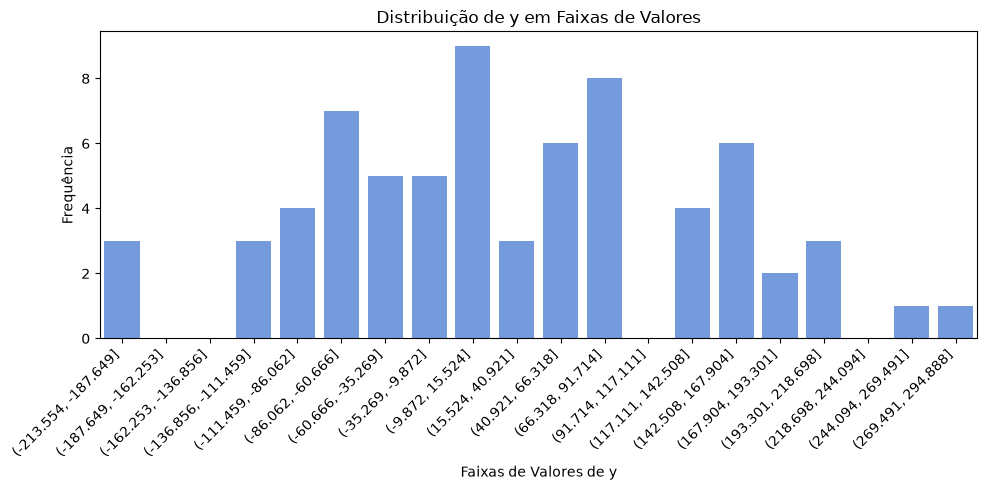

In [144]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Divide os valores de y em faixas (bins) e conta a frequência de cada uma
faixas = pd.cut(df["target"], bins=20).value_counts().sort_index().reset_index()
faixas.columns = ["faixa_y", "contagem"]

# 2. Plota as faixas no eixo X e a contagem no eixo Y
plt.figure(figsize=(10, 5))
sns.barplot(
    data=faixas,
    x=faixas["faixa_y"].astype(str),
    y="contagem",
    color="cornflowerblue",
)

plt.title("Distribuição de y em Faixas de Valores")
plt.xlabel("Faixas de Valores de y")
plt.ylabel("Frequência")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Pondo em prática: Ridge e Lasso

Serão aplicadas as regressões Ridge, Lasso e linear múltipla sobre um mesmo dataset para comparar o desempenho e interpretar a modelagem de cada uma delas. O dataset escolhido possui dados sobre mais de 700 faculdades nos Estados Unidos, de acordo com a edição de 1995 do *US News and World Report* [7]. Esse dataset vem do módulo de python `ISLP`, disponível em [8], do qual usaremos a função `load_data` para carregar os dados `College`. Como variáveis, ele apresenta:

* `Private`: Fator com os níveis "No" e "Yes", indicando se a universidade é pública ou privada
* `Apps`: Número de inscrições/candidaturas recebidas
* `Accept`: Número de inscrições/candidaturas aceitas
* `Enroll`: Número de novos alunos matriculados
* `Top10perc`: Porcentagem de novos alunos vindos dos 10% melhores do ensino médio
* `Top25perc`: Porcentagem de novos alunos vindos dos 25% melhores do ensino médio
* `F.Undergrad`: Número de alunos de graduação em tempo integral (*full-time*)
* `P.Undergrad`: Número de alunos de graduação em meio período (*part-time*)
* `Outstate`: Mensalidade/anuidades para alunos de fora do estado
* `Room.Board`: Custos de moradia e alimentação
* `Books`: Custos estimados com livros
* `Personal`: Gastos pessoais estimados
* `PhD`: Porcentagem do corpo docente com doutorado (Ph.D.)
* `Terminal`: Porcentagem do corpo docente com a titulação máxima exigida na área (*terminal degree*)
* `S.F.Ratio`: Razão entre alunos e professores (*student/faculty ratio*)
* `perc.alumni`: Porcentagem de ex-alunos que fazem doações para a instituição
* `Expend`: Gastos instrucionais/pedagógicos por aluno
* `Grad.Rate`: Taxa de graduação/conclusão de curso

Sendo que `Apps` será utilizado como variável alvo.

In [76]:
# Importando dados do ISLP
from ISLP import load_data
college_df = load_data('College')
college_df.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


A variável `Private` é categórica, então um algoritmo regressivo não é capaz de interpretá-la nessa forma nominal. Logo, como ela é binária ("Yes" ou "No"), ela será codificada através do `OneHotEncoder` para criar dois atributos: `Private_no` e `Private_yes`.

In [77]:
from sklearn.preprocessing import OneHotEncoder

In [78]:
var_catg = ["Private"]
var_num = [c for c in college_df.columns if c not in var_catg]

codificador = OneHotEncoder(sparse_output=False)

# Codifica apenas a categórica Private
cat_codificada = codificador.fit_transform(college_df[var_catg])

# Cria DataFrame com as novas colunas Private_no e Private_yes
df_codificado = pd.DataFrame(
    cat_codificada,
    columns=codificador.get_feature_names_out(var_catg),
    index=college_df.index
)

# Junta variáveis numéricas e codificadas
df = pd.concat([college_df[var_num], df_codificado], axis=1);

Realizando a divisão treino-teste:

In [79]:
TAMANHO_TESTE = 0.1
SEMENTE = 42 

indices = df.index
indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE,
    random_state=SEMENTE
)
# Divisão de observações para treino e para teste
df_treino = df.iloc[indices_treino]
df_teste = df.iloc[indices_teste]

nome_y="Apps"

# Atribuição de cada conjunto correspondente
X_treino = df_treino.drop(nome_y, axis=1)
y_treino = df_treino[nome_y]

X_teste = df_teste.drop(nome_y, axis=1)
y_teste = df_teste[nome_y]

### Aplicando os modelos

Como o dataset inclui atributos com diferentes escalas de magnitude, todos os modelos terão os dados padronizados através da função `StandardScaler()`, que se baseia no z-score. Iniciemos pela regressão linear.

In [80]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [81]:
# Instanciando o pipeline
rlm_pipeline = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

# Treinando modelo
rlm_pipeline.fit(X_treino, y_treino)

# Gerando previsão
previsao_rlm = rlm_pipeline.predict(X_teste)

In [82]:
# Obtendo métricas
rmse_rlm = root_mean_squared_error(previsao_rlm, y_teste)
r2_rlm = r2_score(y_teste, previsao_rlm)

# Apresentando resutlados
print(
    "Métricas da RLM:",
    "-" * 20,
    f"R²: {r2_rlm:.2f}", 
    f"RMSE: {rmse_rlm:.2f}",
    sep="\n"
    )

Métricas da RLM:
--------------------
R²: 0.89
RMSE: 1094.83


Partindo para a regressão Ridge:

In [83]:
import numpy as np
from sklearn.linear_model import RidgeCV

In [84]:
# Definindo espaço de lambdas
lambdas = np.logspace(start=3, stop=-3, num=200) 

# Instanciando pipeline
ridge_pipeline = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=lambdas, cv=5)
)

# Treinando pipeline
ridge_pipeline.fit(X_treino, y_treino)

# Realizando previsão
previsao_ridge = ridge_pipeline.predict(X_teste)

In [85]:
# Obtendo métricas
rmse_lasso = root_mean_squared_error(previsao_ridge, y_teste)
r2_lasso = r2_score(y_teste, previsao_ridge)
melhor_lambda = ridge_pipeline.named_steps['ridgecv'].alpha_

# Apresentando resultados
print(
    "Métricas da Ridge:",
    "-" * 20,
    f"Melhor λ: {melhor_lambda:.3f}",
    f"R²: {r2_lasso:.2f} \nRMSE: {rmse_lasso:.2f}",
    sep="\n"
    )

Métricas da Ridge:
--------------------
Melhor λ: 5.873
R²: 0.90 
RMSE: 1069.86


Agora com a regressão Lasso:

In [86]:
from sklearn.linear_model import LassoCV

In [87]:
# Definindo espaço dos alphas
alphas = np.logspace(-3, 3, num=200)

# Instanciando pipeline com padronização e lasso
lasso_pipeline = make_pipeline(
    StandardScaler(),
    LassoCV(alphas=alphas, cv=5, n_jobs=-1, random_state=42) # n_jobs=-1: usa todos os núcleos disponíveis
)

# Treinando modelo
lasso_pipeline.fit(X_treino, y_treino)

# Realisando previsão
previsao_lasso = lasso_pipeline.predict(X_teste)

In [88]:
# Obtendo métricas
rmse_lasso = root_mean_squared_error(y_teste, previsao_lasso)
r2_lasso = r2_score(y_teste, previsao_lasso)
melhor_alpha = lasso_pipeline.named_steps['lassocv'].alpha_
coef_zerados = len([c for c in lasso_pipeline.named_steps['lassocv'].coef_ if abs(c) < 0.00001])

# Apresentando métricas
print(
    "Métricas do Lasso:",
    "-" * 20,
    f"Melhor alpha: {melhor_alpha:.2f}",
    f"R²: {r2_lasso:.2f}", f"RMSE: {rmse_lasso:.2f}",
    f"Coeficientes zerados: {coef_zerados}",
    sep="\n"
    )

Métricas do Lasso:
--------------------
Melhor alpha: 20.49
R²: 0.90
RMSE: 1060.46
Coeficientes zerados: 4


Vamos calcular o viés e a variância dos modelos a partir de `bias_variance_decomp`, definindo novos pipelines com o melhor $\alpha$ ou $\lambda$ já informado.

In [89]:
from mlxtend.evaluate import bias_variance_decomp

### Avaliando os desempenhos

<table style="width: 100%; border-collapse: collapse; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; border-radius: 8px; overflow: hidden; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); font-size: 13.5px; border: 1px solid #cbd5e1;">
  <thead>
    <tr style="background-color: #0f172a; color: #ffffff;">
      <th style="padding: 12px 16px; text-align: left; border: 1px solid #334155;">Modelo</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">R²</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">RMSE</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">log(Vi&eacute;s&sup2;)</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">Vari&acirc;ncia</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">Hiperpar&acirc;metro</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">Coef. Zerados</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #ffffff;">
      <td style="padding: 11px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">RLM</td>
      <td style="padding: 11px 14px; text-align: center; font-weight: 600; color: #0f172a; border: 1px solid #e2e8f0;">0.89</td>
      <td style="padding: 11px 14px; text-align: center; font-weight: 600; color: #0f172a; border: 1px solid #e2e8f0;">1094.83</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">12.14</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">74585.96</td>
      <td style="padding: 11px 14px; text-align: center; color: #94a3b8; border: 1px solid #e2e8f0;">&mdash;</td>
      <td style="padding: 11px 14px; text-align: center; color: #94a3b8; border: 1px solid #e2e8f0;">&mdash;</td>
    </tr>
    <tr style="background-color: #f8fafc;">
      <td style="padding: 11px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">Ridge</td>
      <td style="padding: 11px 14px; text-align: center; font-weight: 600; color: #0f172a; border: 1px solid #e2e8f0;">0.90</td>
      <td style="padding: 11px 14px; text-align: center; font-weight: 600; color: #0f172a; border: 1px solid #e2e8f0;">1069.99</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">12.10</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">68604.46</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">&lambda; = 5.83</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">0</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 11px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">Lasso</td>
      <td style="padding: 11px 14px; text-align: center; font-weight: 600; color: #0f172a; border: 1px solid #e2e8f0;">0.90</td>
      <td style="padding: 11px 14px; text-align: center; font-weight: 600; color: #0f172a; border: 1px solid #e2e8f0;">1059.48</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">12.09</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">49803.96</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">&alpha; = 21.40</td>
      <td style="padding: 11px 14px; text-align: center; font-weight: 600; color: #0f172a; border: 1px solid #e2e8f0;">3</td>
    </tr>
  </tbody>
</table>

Podemos verificar que todos os três modelos obtiveram bons resultados no treino em termos de $R^2$ <CONTINUAR

### Analisando os coeficientes

In [90]:
coef_df = pd.DataFrame({
    'Atributo': X_treino.columns,
    'Coeficientes lasso': lasso_pipeline.named_steps['lassocv'].coef_,
    'Coeficientes ridge': ridge_pipeline.named_steps['ridgecv'].coef_,
    'Coeficientes de RLM': rlm_pipeline.named_steps["linearregression"].coef_
}).sort_values(by='Coeficientes lasso', ascending=False, key=abs) # Opcional: ordena por magnitude (importância)

coef_df.style.hide(axis='index')

Atributo,Coeficientes lasso,Coeficientes ridge,Coeficientes de RLM
Accept,3711.206612,3746.523157,4007.303306
Top10perc,638.764697,803.230989,891.271117
Expend,343.136804,391.071654,386.004921
Enroll,-284.467348,-570.444732,-912.287551
Private_No,221.626732,131.413546,129.195107
Outstate,-221.412804,-280.376956,-318.475756
Room.Board,136.098745,184.973499,173.157251
PhD,-134.370710,-174.103052,-189.451181
Grad.Rate,104.049017,163.834162,156.226382
Top25perc,-84.727482,-229.522999,-293.638214


In [91]:
from sklearn.linear_model import ElasticNetCV

# Definindo modelo de ElasticNet
pipeline_enet = make_pipeline(
    StandardScaler(),
    ElasticNetCV(l1_ratio=[0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 0.99 ,1], cv=5, n_jobs=-1)
)

# Treinando modelo
pipeline_enet.fit(X_treino, y_treino)

# Realizando previsão
enet_previsao = pipeline_enet.predict(X_teste)

In [92]:
# Obtendo métricas
r2_enet = r2_score(y_teste, enet_previsao)
rmse_enet = root_mean_squared_error(y_teste, enet_previsao)
melhor_razao = pipeline_enet.named_steps['elasticnetcv'].l1_ratio_
melhor_alpha_enet = pipeline_enet.named_steps['elasticnetcv'].alpha_
coef_zerados_enet = len([c for c in pipeline_enet.named_steps['elasticnetcv'].coef_ if abs(c) < 0.0001])


# Apresentando métricas
print(
    "Métricas do Elastic Net:",
    "-" * 20,
    f"Melhor razão L1: {melhor_razao}",
    f"Melhor alpha: {melhor_alpha_enet:.2f}",
    f"R²: {r2_enet:.2f}", f"RMSE: {rmse_enet:.2f}",
    f"Coeficientes zerados: {coef_zerados_enet}",
    sep="\n"
    )

Métricas do Elastic Net:
--------------------
Melhor razão L1: 1.0
Melhor alpha: 21.23
R²: 0.90
RMSE: 1059.66
Coeficientes zerados: 4


In [93]:
melhor_ridge = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=[melhor_lambda], cv=5)
)

melhor_lasso = make_pipeline(
    StandardScaler(),
    LassoCV(alphas=[melhor_alpha], cv=5, n_jobs=-1)
)

melhor_enet = make_pipeline(
    StandardScaler(),
    ElasticNetCV(alphas=[melhor_alpha_enet], l1_ratio=[melhor_razao], cv=5, n_jobs=-1)
)

for modelo, nome in zip(
    [rlm_pipeline, melhor_ridge, melhor_lasso, melhor_enet],
    ["RLM", "Ridge", "Lasso", "ElasticNet"]
    ):
    _, sq_bias, var = bias_variance_decomp(
        modelo, 
        X_treino, y_treino, 
        X_teste, y_teste, 
        loss='mse', 
        num_rounds=200, 
        random_seed=42
    )
    print(
        f"{nome}:",
        f"- Log(Bias²): {np.log10(sq_bias):.2f}\n- Var:{var:.2f}",
        "-" * 20,
        sep="\n"
    )

RLM:
- Log(Bias²): 6.07
- Var:74585.96
--------------------
Ridge:
- Log(Bias²): 6.05
- Var:68573.32
--------------------
Lasso:
- Log(Bias²): 6.05
- Var:50400.67
--------------------
ElasticNet:
- Log(Bias²): 6.04
- Var:49915.98
--------------------


## Vidros 🫙

<EXPLICAÇÃO DO DATASET

In [94]:
df = pd.read_pickle("data/refractive_index.pkl")
y = df.pop("Indice de Refração")

# Deixando índices na ordem certa
indices = range(len(df))

df.index = indices
y.index = indices

Divisão treino-teste

In [95]:
TAMANHO_TESTE = 0.1
SEMENTE = 42 

indices = df.index
indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE,
    random_state=SEMENTE
)

# Atribuição de cada conjunto correspondente

X_treino = df.loc[indices_treino]
X_teste = df.loc[indices_teste]

y_treino = y.loc[indices_treino]
y_teste = y.loc[indices_teste]


In [96]:
rlm = make_pipeline(
    StandardScaler(),
    LinearRegression(),
)

rlm.fit(X_treino, y_treino)

previsao_rlm = rlm.predict(X_teste)

In [97]:
r2_rlm = r2_score(y_teste, previsao_rlm)
rmse_rlm = root_mean_squared_error(y_teste, previsao_rlm)

print(
    "Métricas da RLM:",
    "-" * 20,
    f"R²: {r2_rlm:.2f}", 
    f"RMSE: {rmse_rlm:.2f}",
    sep="\n"
    )

Métricas da RLM:
--------------------
R²: 0.87
RMSE: 0.07


In [98]:
lambdas = np.logspace(3, -3, num=200)

ridge = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=lambdas, cv=5)
    )

ridge.fit(X_treino, y_treino)

ridge_previsao = ridge.predict(X_teste)

In [99]:
r2_ridge = r2_score(y_teste, ridge_previsao)
rmse_ridge = root_mean_squared_error(y_teste, ridge_previsao)
melhor_lambda = ridge.named_steps["ridgecv"].alpha_

print(
    "Métricas do Ridge:",
    "-" * 20,
    f"Melhor lambda: {melhor_lambda:.2f}",
    f"R²: {r2_ridge:.2f}", 
    f"RMSE: {rmse_ridge:.2f}",
    sep="\n"
    )

Métricas do Ridge:
--------------------
Melhor lambda: 307.21
R²: 0.87
RMSE: 0.07


In [100]:
alphas = np.logspace(-3, 3, num=200)

lasso = make_pipeline(
    StandardScaler(),
    LassoCV(alphas=alphas, cv=5, max_iter=10_000, n_jobs=-1)
    )

lasso.fit(X_treino, y_treino)

lasso_previsao = lasso.predict(X_teste)

In [101]:
r2_lasso = r2_score(y_teste, lasso_previsao)
rmse_lasso = root_mean_squared_error(y_teste, lasso_previsao)
melhor_alpha = lasso.named_steps["lassocv"].alpha_
coef_zerados = len([c for c in lasso.named_steps['lassocv'].coef_ if abs(c) == 0])

print(
    "Métricas do Lasso:",
    "-" * 20,
    f"Número de coeficientes zerados: {coef_zerados}",
    f"Melhor alpha: {melhor_alpha:.4f}",
    f"R²: {r2_lasso:.2f}",
    f"RMSE: {rmse_lasso:.2f}",
    sep="\n"
    )

Métricas do Lasso:
--------------------
Número de coeficientes zerados: 29
Melhor alpha: 0.0010
R²: 0.87
RMSE: 0.07


In [102]:
coef_df = pd.DataFrame({
    'Atributo': X_treino.columns,
    'Coeficientes lasso': lasso.named_steps['lassocv'].coef_,
    'Coeficientes ridge': ridge.named_steps['ridgecv'].coef_,
    'Coeficientes de RLM': rlm.named_steps["linearregression"].coef_
}).sort_values(by='Coeficientes lasso', ascending=False, key=abs) # Opcional: ordena por magnitude (importância)

coef_df.style.hide(axis='index')

Atributo,Coeficientes lasso,Coeficientes ridge,Coeficientes de RLM
SiO2,-0.067767,-0.053593,6.108897
Bi2O3,0.062212,0.066131,1.443933
TiO2,0.054295,0.059237,2.064150
P2O5,-0.050997,-0.044773,3.428576
PbO,0.047108,0.053150,2.123705
TeO2,0.047072,0.053053,2.485391
Nb2O5,0.038531,0.042053,1.124099
B2O3,-0.038366,-0.029780,4.463605
La2O3,0.028402,0.031592,1.499541
Na2O,-0.019129,-0.014623,1.796529


## E com poucas observações?

In [103]:
TAMANHO_TESTE = 0.995
SEMENTE = 42 

indices = df.index
indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE,
    random_state=SEMENTE
)

# Atribuição de cada conjunto correspondente
X_treino = df.loc[indices_treino]
X_teste = df.loc[indices_teste]

y_treino = y.loc[indices_treino]
y_teste = y.loc[indices_teste]

In [104]:
rlm = make_pipeline(
    LinearRegression()
)

rlm.fit(X_treino, y_treino)

previsao_rlm = rlm.predict(X_teste)

In [105]:
r2_rlm = r2_score(y_teste, previsao_rlm)
rmse_rlm = root_mean_squared_error(y_teste, previsao_rlm)
coef_zerados = len([c for c in rlm.named_steps['linearregression'].coef_ if abs(c) == 0])

print(
    "Métricas da RLM:",
    f"Coeficientes zerados: {coef_zerados}",
    "-" * 20,
    f"R²: {r2_rlm:.2f}", 
    f"RMSE: {rmse_rlm:.2f}",
    sep="\n"
    )

Métricas da RLM:
Coeficientes zerados: 27
--------------------
R²: -119981.02
RMSE: 64.73


In [106]:
lambdas = np.logspace(3, -3, num=200)

ridge = make_pipeline(
    RidgeCV(alphas=lambdas, cv=5)
    )

ridge.fit(X_treino, y_treino)

ridge_previsao = ridge.predict(X_teste)

In [107]:
r2_ridge = r2_score(y_teste, ridge_previsao)
rmse_ridge = root_mean_squared_error(y_teste, ridge_previsao)
melhor_lambda = ridge.named_steps["ridgecv"].alpha_
coef_zerados = len([c for c in ridge.named_steps['ridgecv'].coef_ if abs(c) == 0])

print(
    "Métricas do Ridge:",
    "-" * 20,
    f"Coeficientes zerados: {coef_zerados}",
    f"Melhor lambda: {melhor_lambda:.2f}",
    f"R²: {r2_ridge:.2f}", 
    f"RMSE: {rmse_ridge:.2f}",
    sep="\n"
    )

Métricas do Ridge:
--------------------
Coeficientes zerados: 34
Melhor lambda: 465.95
R²: 0.88
RMSE: 0.06


In [108]:
alphas = np.logspace(-3, 3, num=200)

lasso = make_pipeline(
    LassoCV(alphas=alphas, cv=5, max_iter=10_000, n_jobs=-1)
    )

lasso.fit(X_treino, y_treino)

lasso_previsao = lasso.predict(X_teste)

In [109]:
r2_lasso = r2_score(y_teste, lasso_previsao)
rmse_lasso = root_mean_squared_error(y_teste, lasso_previsao)
melhor_alpha = lasso.named_steps["lassocv"].alpha_
coef_zerados = len([c for c in lasso.named_steps['lassocv'].coef_ if abs(c) == 0])

print(
    "Métricas do Lasso:",
    "-" * 20,
    f"Número de coeficientes zerados: {coef_zerados}",
    f"Melhor alpha: {melhor_alpha:.4f}",
    f"R²: {r2_lasso:.2f}",
    f"RMSE: {rmse_lasso:.2f}",
    sep="\n"
    )

Métricas do Lasso:
--------------------
Número de coeficientes zerados: 57
Melhor alpha: 0.0043
R²: 0.88
RMSE: 0.07


<!-- VER PROXIMA CELULA -->
<!-- Aqui eu posso argumentar como  há materiais tão raros nos vidros que pode ser que eles sequer tenham aparecido no treinamento ou que tenham aprecido muito pouco, então os modelos facilmente zeram eles.-->

In [110]:
atributos_raros = []
for atributo in df.columns:
    contagem = (df[atributo] != 0).sum()
    if contagem <= 420:
        # print(f"{atributo}: {contagem}")
        atributos_raros.append((atributo, contagem.item()))

sorted(atributos_raros, key=lambda a: a[1])
len(atributos_raros)

51

In [111]:
coef_df = pd.DataFrame({
    'Atributo': X_treino.columns,
    'Coeficientes lasso': lasso.named_steps['lassocv'].coef_,
    'Coeficientes ridge': ridge.named_steps['ridgecv'].coef_,
    'Coeficientes de RLM': rlm.named_steps["linearregression"].coef_
}).sort_values(by='Coeficientes lasso', ascending=False, key=abs) # Opcional: ordena por magnitude (importância)

coef_df.style.hide(axis='index')

Atributo,Coeficientes lasso,Coeficientes ridge,Coeficientes de RLM
Bi2O3,0.010856,0.008753,-16.782601
Gd2O3,0.008412,0.004532,-16.783907
ZrO2,0.007627,0.004873,-16.785341
Nb2O5,0.006227,0.004968,-16.787211
V2O5,0.005237,0.004265,-16.788730
TiO2,0.004269,0.003860,-16.789758
P2O5,-0.004239,-0.005119,-16.798445
K2O,-0.003842,-0.004555,-16.798177
Na2O,-0.003641,-0.004386,-16.797595
SiO2,-0.003572,-0.004424,-16.797585


## Apêndice - Códigos para o gráfico das figuras

### Figura 2

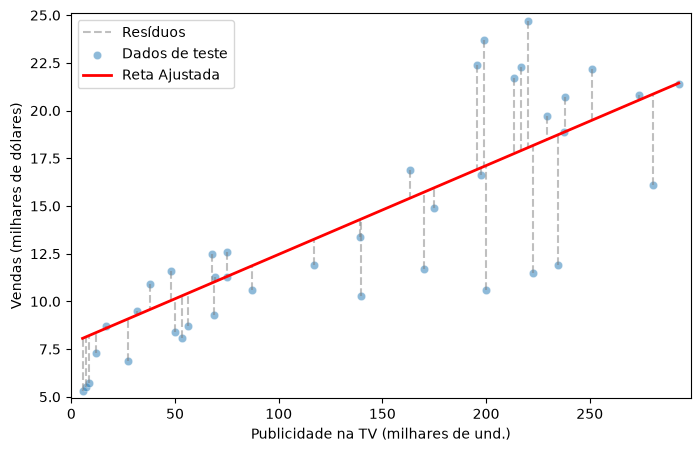

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ajustes visuais
plt.figure(figsize=(8, 5))
plt.margins(x=0.02, y=0.02)
plt.xlabel("Publicidade na TV (milhares de und.)")
plt.ylabel("Vendas (milhares de dólares)")

# Adicionando cada linha dos reísudos (IA)
plt.vlines(
    x=x_teste,
    ymin=y_teste,
    ymax=previsao,
    colors="gray",
    linestyles="dashed",
    alpha=0.5,
    label="Resíduos",
)
plt.legend()

# Plota dados de entrada e reta ajustada
eixo = sns.scatterplot(x=x_teste, y=y_teste, alpha=0.5, label="Dados de teste")
sns.lineplot(x=x_teste, y=previsao, color="red", linewidth=2, label="Reta Ajustada");

### Figura 3

#### Superfície de Regressão

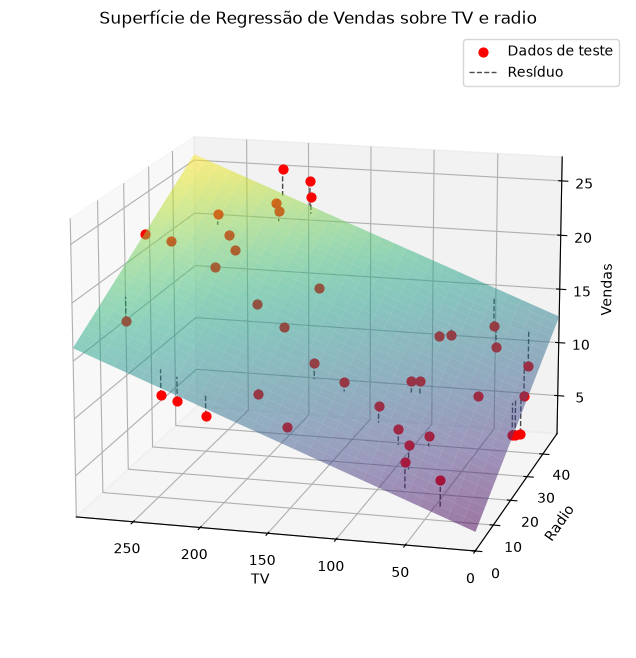

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

max_tv = X_teste_rlm["TV"].max()
max_radio = X_teste_rlm["radio"].max()

tv_range = np.linspace(0, max_tv, 30)
radio_range = np.linspace(0, max_radio, 30)
TV_grid, RADIO_grid = np.meshgrid(tv_range, radio_range)

grid_df = pd.DataFrame({
    "TV": TV_grid.ravel(),
    "radio": RADIO_grid.ravel()
})
Z_grid = modelo_rlm.predict(grid_df).reshape(TV_grid.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    TV_grid, 
    RADIO_grid, 
    Z_grid, 
    cmap=sns.color_palette("viridis", as_cmap=True),
    edgecolor='none',
    alpha=0.5
)

ax.scatter(
    X_teste_rlm["TV"], 
    X_teste_rlm["radio"], 
    y_teste, 
    color='red', 
    s=40, 
    label='Dados de teste',
    depthshade=False
)

for i, (tv, radio, z_actual, z_pred) in enumerate(
    zip(X_teste_rlm["TV"], X_teste_rlm["radio"], y_teste, previsao_rlm)
):
    ax.plot(
        [tv, tv],
        [radio, radio],
        [z_actual, z_pred],
        color="black",
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        label="Resíduo" if i == 0 else None,
    )


# Inverter o eixo X faz com que o 0 do TV e o 0 do Radio se encontrem no vértice frontal
ax.set_xlim(max_tv, 0)
ax.set_ylim(0, max_radio)

# Ângulo de câmera ideal para ver o canto (0,0) de frente
ax.view_init(elev=15, azim=-75)

ax.set_xlabel("TV")
ax.set_ylabel("Radio")
ax.set_zlabel("Vendas")
ax.set_title("Superfície de Regressão de Vendas sobre TV e radio")
plt.legend()

plt.show()

#### Desempenho

TODO

## Agradecimentos

- Rômulo, Jônatas, Edélio, Vinícius Cútolo...

## Referências 


[1] https://www.geeksforgeeks.org/machine-learning/ml-linear-regression/

[2] https://www.statlearning.com/

[3] https://statisticsfundamentals.com/simple-linear-regression/rmse/

[4] https://statisticsfundamentals.com/pearson-correlation/

[5] https://scienceinsights.org/what-is-collinearity-and-how-does-it-affect-regression/

[6?] https://scienceinsights.org/when-to-use-spearman-correlation-vs-pearson/ 

[6] https://www.nature.com/articles/s43586-021-00056-9

[7] https://islp.readthedocs.io/en/latest/datasets/College.html#u-s-news-and-world-report-s-college-data

[8] https://intro-stat-learning.github.io/ISLP/installation.html



<div style="width: 100%; text-align: center; margin-bottom: 20px;">
  <img src="images/rodape_eleicao.png" alt="Rodapé" style="max-width: 100%; height: auto;">
</div>